## Imports
Load numerical, signal I/O, deep learning, and plotting libraries.

In [1]:
import numpy as np
import scipy.io as scio
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

## Data Loading
Load ventricular ECG arrays, concatenate them, and select one lead per subject.

In [2]:
Rva1 = scio.loadmat("Rva1.mat")["Rva1"]
Rva2 = scio.loadmat("Rva2.mat")["Rva2"]
Rva3 = scio.loadmat("Rva3.mat")["Rva3"]
Xva = np.concatenate([Rva1, Rva2, Rva3], axis=2).astype(np.float32)  # (12,15000,75)

fs = 256

# Choose lead for detection (Lead II is usually strong)
lead = 1  # 0=I, 1=II, ...
X = Xva[lead, :, :]  # (15000,75)
X = np.transpose(X, (1,0))  # (75,15000)

    1) Pseudo-label creation

In [3]:
def simple_r_peaks(x, fs=256):
    x = x - x.mean()
    x = x / (x.std() + 1e-6)
    xdet = np.abs(x)

    min_dist = int(0.25 * fs)     # 250 ms
    thr = 0.6 * xdet.max()

    peaks = []
    i = 0
    n = len(xdet)
    while i < n:
        if xdet[i] > thr:
            # local max within a window
            j = min(i + min_dist, n)
            k = i + np.argmax(xdet[i:j])
            peaks.append(k)
            i = k + min_dist
        else:
            i += 1
    return np.array(peaks, dtype=int)

def gaussian_targets(length, peaks, sigma=8):
    # sigma in samples (~8 samples = 31 ms at 256 Hz)
    y = np.zeros(length, dtype=np.float32)
    if len(peaks) == 0:
        return y
    idx = np.arange(length)
    for p in peaks:
        y += np.exp(-0.5 * ((idx - p) / sigma) ** 2)
    y = np.clip(y, 0.0, 1.0)
    return y

Y = []
peaks_all = []
for s in range(X.shape[0]):
    p = simple_r_peaks(X[s], fs)
    peaks_all.append(p)
    Y.append(gaussian_targets(X.shape[1], p, sigma=8))
Y = np.stack(Y)  # (75,15000)

print("X:", X.shape, "Y:", Y.shape)


X: (75, 15000) Y: (75, 15000)


    2) Windowing dataset

In [4]:
WIN = 2048
STRIDE = 512

def make_windows_rdet(X, Y, win=WIN, stride=STRIDE):
    xs, ys = [], []
    for s in range(X.shape[0]):
        x = X[s]
        y = Y[s]
        for start in range(0, len(x) - win + 1, stride):
            xs.append(x[start:start+win])
            ys.append(y[start:start+win])
    xs = np.stack(xs)[..., None]  # (N,WIN,1)
    ys = np.stack(ys)[..., None]  # (N,WIN,1)
    return xs.astype(np.float32), ys.astype(np.float32)

Xw, Yw = make_windows_rdet(X, Y)

# Normalize input windows
mu = Xw.mean(axis=1, keepdims=True)
sd = Xw.std(axis=1, keepdims=True) + 1e-6
Xw_n = (Xw - mu) / sd

    3) Train/val split

In [5]:
n = Xw_n.shape[0]
perm = np.random.permutation(n)
ntr = int(0.85*n)
tr_idx, va_idx = perm[:ntr], perm[ntr:]

Xtr, Ytr = Xw_n[tr_idx], Yw[tr_idx]
Xva, Yva = Xw_n[va_idx], Yw[va_idx]

    4) Model: 1D CNN -> sigmoid per sample

In [6]:
def build_r_detector(win=WIN):
    inp = layers.Input(shape=(win,1))
    x = inp
    for filters in [16, 32, 32, 64]:
        x = layers.Conv1D(filters, 9, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
    x = layers.Conv1D(1, 1, padding="same")(x)
    out = layers.Activation("sigmoid")(x)
    return models.Model(inp, out)

rdet = build_r_detector()
rdet.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
             loss="binary_crossentropy")

rdet.summary()

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1),
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, verbose=1),
]

rdet.fit(Xtr, Ytr, validation_data=(Xva, Yva),
         epochs=30, batch_size=64, callbacks=callbacks)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2048, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 2048, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2048, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 2048, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 2048, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 2048, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 2048, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 2048, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 2048, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2048, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 2048, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 2048, 1)        │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 2048, 1)        │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 32,897 (128.50 KB)

 Non-trainable params: 288 (1.12 KB)

Epoch 1/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step - loss: 0.3595 - val_loss: 0.5301 - learning_rate: 0.0010
Epoch 2/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 0.1798 - val_loss: 0.3601 - learning_rate: 0.0010
Epoch 3/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.1450 - val_loss: 0.2827 - learning_rate: 0.0010
Epoch 4/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - loss: 0.1298 - val_loss: 0.2319 - learning_rate: 0.0010
Epoch 5/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 0.1219 - val_loss: 0.1983 - learning_rate: 0.0010
Epoch 6/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 0.1170 - val_loss: 0.1716 - learning_rate: 0.0010
Epoch 7/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.1132 - val_loss: 0.1599 - learning_rate: 0.0010
Epoch 8/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - loss: 0.1109 - val_loss: 0.1523 - learning_rate: 0.0010
Epoch 9/30
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - loss: 0.1089 - val_loss: 0.1496 - learning_rate: 0.0010
Epoch 10/3

    5) Inference on one subject + peak picking

In [7]:
def pick_peaks_from_prob(prob, fs=256, thr=0.5):
    # simple peak picking on probability signal
    min_dist = int(0.25 * fs)
    peaks = []
    i = 0
    n = len(prob)
    while i < n:
        if prob[i] > thr:
            j = min(i + min_dist, n)
            k = i + np.argmax(prob[i:j])
            peaks.append(k)
            i = k + min_dist
        else:
            i += 1
    return np.array(peaks, dtype=int)

s = 0
x = X[s]
x_n = (x - x.mean()) / (x.std() + 1e-6)

## Windowed Inference
Apply the trained detector to padded chunks and stitch probabilities into one sequence.

In [8]:
# Run model on sliding windows and stitch (simple: run one big chunk by padding)
pad = (-len(x_n)) % WIN
x_pad = np.pad(x_n, (0,pad), mode="constant")
x_chunks = x_pad.reshape(-1, WIN, 1).astype(np.float32)

p_chunks = rdet.predict(x_chunks, verbose=0)[:, :, 0]
p = p_chunks.reshape(-1)[:len(x_n)]

peaks_pred = pick_peaks_from_prob(p, fs=fs, thr=0.5)

## Visualization
Plot normalized ECG, predicted probability, and detected peak locations.

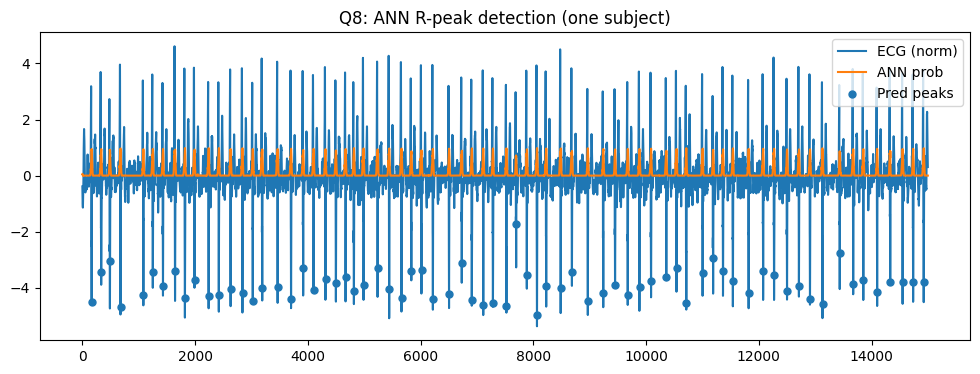

In [9]:
plt.figure(figsize=(12,4))
plt.plot(x_n, label="ECG (norm)")
plt.plot(p, label="ANN prob")
plt.scatter(peaks_pred, x_n[peaks_pred], s=25, label="Pred peaks")
plt.legend()
plt.title("Q8: ANN R-peak detection (one subject)")
plt.show()